# 04 — Price Elasticity
Estimate price elasticity of demand per product.

**Elasticity** = % change in quantity / % change in price

- Elasticity < -1 → elastic (price sensitive, raising price loses revenue)
- Elasticity between -1 and 0 → inelastic (price insensitive, raising price gains revenue)
- Elasticity > 0 → unusual (Giffen good or data artefact)

**Approach:** Log-log OLS regression per product on monthly data. `log(qty) ~ log(price)`. The coefficient on log(price) is the elasticity estimate.

**Output:** `data/processed/elasticity.parquet` with elasticity per product.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, warnings
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
PROCESSED = Path('../data/processed')
print('Imports OK')

Imports OK


## 1. Load data

In [2]:
monthly  = pd.read_parquet(PROCESSED / 'monthly_features.parquet')
products = pd.read_parquet(PROCESSED / 'product_features.parquet')
print(f'Monthly rows : {len(monthly):,}')
print(f'Products     : {len(products):,}')
monthly.head()

Monthly rows : 30,336
Products     : 3,665


,StockCode,InvoiceMonth,monthly_quantity,monthly_revenue,avg_price,num_orders,num_customers,qty_lag1,qty_growth
0,10002,2010-12,224,190.40,0.85,16,15,NaN,NaN
1,10002,2011-01,337,286.45,0.85,18,18,224.0,0.502222
2,10002,2011-02,50,42.50,0.85,5,5,337.0,-0.849112
3,10002,2011-03,23,19.55,0.85,5,5,50.0,-0.529412
4,10002,2011-04,189,160.65,0.85,5,5,23.0,6.916667


## 2. Filter products with enough price variation

In [3]:
# Need at least 4 months of data and some price variation to estimate elasticity
monthly_counts = monthly.groupby('StockCode').agg(
    n_months=('InvoiceMonth', 'count'),
    price_std=('avg_price', 'std'),
    price_mean=('avg_price', 'mean')
).reset_index()
monthly_counts['price_cv'] = monthly_counts['price_std'] / monthly_counts['price_mean']

eligible = monthly_counts[
    (monthly_counts['n_months'] >= 4) &
    (monthly_counts['price_cv'] > 0.01)
]['StockCode'].tolist()

print(f'Total products      : {len(monthly_counts):,}')
print(f'Eligible for elasticity: {len(eligible):,}')
print(f'Excluded (fixed price)  : {len(monthly_counts) - len(eligible):,}')

Total products      : 3,665
Eligible for elasticity: 1,763
Excluded (fixed price)  : 1,902


## 3. Estimate elasticity via log-log OLS per product

In [4]:
results = []

for sku in eligible:
    sub = monthly[monthly['StockCode'] == sku].copy()
    sub = sub[sub['avg_price'] > 0]
    if len(sub) < 4:
        continue

    log_price = np.log(sub['avg_price'])
    log_qty   = np.log(sub['monthly_quantity'] + 1)

    # Skip if no variance
    if log_price.std() < 1e-6:
        continue

    slope, intercept, r, p_value, se = stats.linregress(log_price, log_qty)

    results.append({
        'StockCode'  : sku,
        'elasticity' : round(slope, 4),
        'r_squared'  : round(r**2, 4),
        'p_value'    : round(p_value, 4),
        'n_months'   : len(sub),
        'avg_price'  : sub['avg_price'].mean().round(2),
        'price_cv'   : sub['avg_price'].std() / sub['avg_price'].mean(),
    })

elasticity_df = pd.DataFrame(results)
elasticity_df = elasticity_df.merge(
    products[['StockCode','description','total_revenue','revenue_rank']], on='StockCode', how='left'
)

print(f'Elasticity estimates: {len(elasticity_df):,} products')
print(f'\nElasticity distribution:')
print(elasticity_df['elasticity'].describe().round(3))

Elasticity estimates: 1,763 products

Elasticity distribution:
count    1763.000
mean       -7.377
std        18.035
min      -149.068
25%        -8.743
50%        -1.992
75%        -0.692
max        61.968
Name: elasticity, dtype: float64


## 4. Classify products by elasticity

In [5]:
def classify(e):
    if e < -1.5:  return 'highly elastic'
    elif e < -0.5: return 'elastic'
    elif e < 0:    return 'inelastic'
    else:          return 'unusual'

elasticity_df['category'] = elasticity_df['elasticity'].apply(classify)
print(elasticity_df['category'].value_counts())
print(f'\nStatistically significant (p<0.05): {(elasticity_df["p_value"] < 0.05).sum()}')

category
highly elastic    1069
unusual            335
elastic            287
inelastic           72
Name: count, dtype: int64

Statistically significant (p<0.05): 651


## 5. Elasticity distribution plot

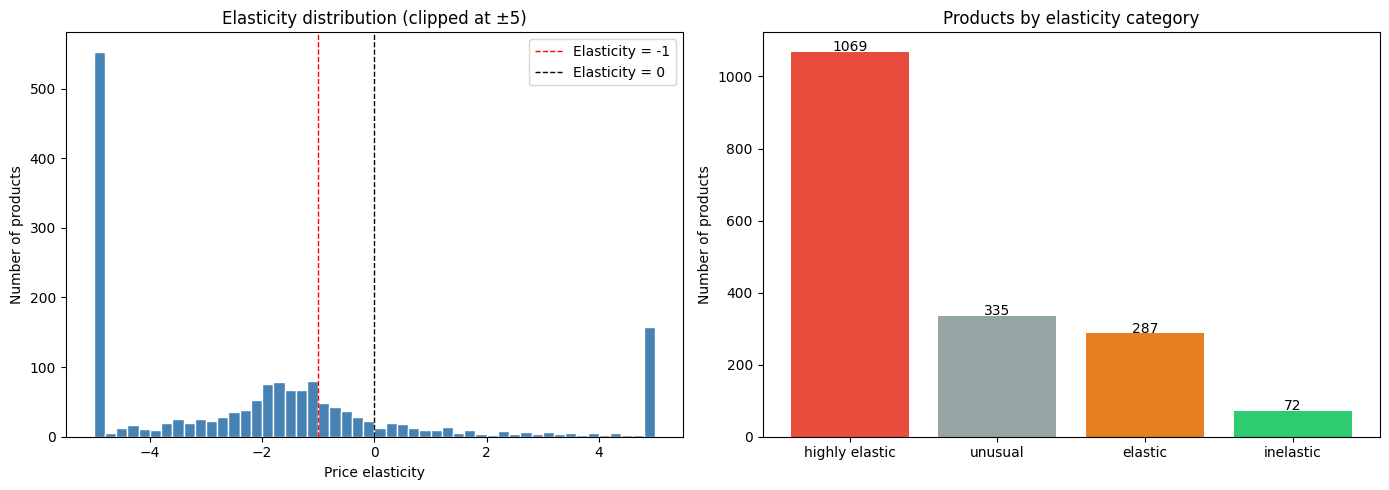

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
clipped = elasticity_df['elasticity'].clip(-5, 5)
axes[0].hist(clipped, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(-1, color='red', linestyle='--', linewidth=1, label='Elasticity = -1')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, label='Elasticity = 0')
axes[0].set_xlabel('Price elasticity')
axes[0].set_ylabel('Number of products')
axes[0].set_title('Elasticity distribution (clipped at ±5)')
axes[0].legend()

# Category breakdown
cats = elasticity_df['category'].value_counts()
colors = {'highly elastic':'#e74c3c','elastic':'#e67e22','inelastic':'#2ecc71','unusual':'#95a5a6'}
axes[1].bar(cats.index, cats.values, color=[colors[c] for c in cats.index])
axes[1].set_title('Products by elasticity category')
axes[1].set_ylabel('Number of products')
for i, v in enumerate(cats.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Most and least price-sensitive products

In [7]:
sig = elasticity_df[elasticity_df['p_value'] < 0.05].copy()

print('=== Most elastic (price-sensitive) — RISKY to raise prices ===')
print(sig.nsmallest(10, 'elasticity')[['description','elasticity','avg_price','total_revenue','r_squared']].to_string(index=False))

print('\n=== Most inelastic — SAFE to raise prices ===')
print(sig[(sig['elasticity'] > -0.5) & (sig['elasticity'] < 0)]
      .nlargest(10, 'total_revenue')[['description','elasticity','avg_price','total_revenue','r_squared']].to_string(index=False))

=== Most elastic (price-sensitive) — RISKY to raise prices ===
                        description  elasticity  avg_price  total_revenue  r_squared
  5 hook hanger red magic toadstool   -113.6444       1.64        4596.75     0.6185
             six drawer office tidy   -101.1670       9.85         605.95     0.9914
           paper bunting white lace    -88.4342       2.89       10264.05     0.8778
      balloon water bomb pack of 35    -88.3746       0.42        2254.14     0.5658
15cm christmas glass ball 20 lights    -87.7168       7.85        9374.70     0.4707
       ceramic strawberry money box    -85.2694       2.53        1859.40     0.7478
  baking mould toffee cup chocolate    -80.7320       2.52        1950.90     0.5845
       vintage union jack memoboard    -78.5364       9.78       22709.13     0.5750
   small ivory heart wall organiser    -72.7168       5.67        5044.66     0.7646
             200 bendy skull straws    -70.4163       1.24         706.30     0.6337

=

## 7. Price vs quantity scatter for sample products

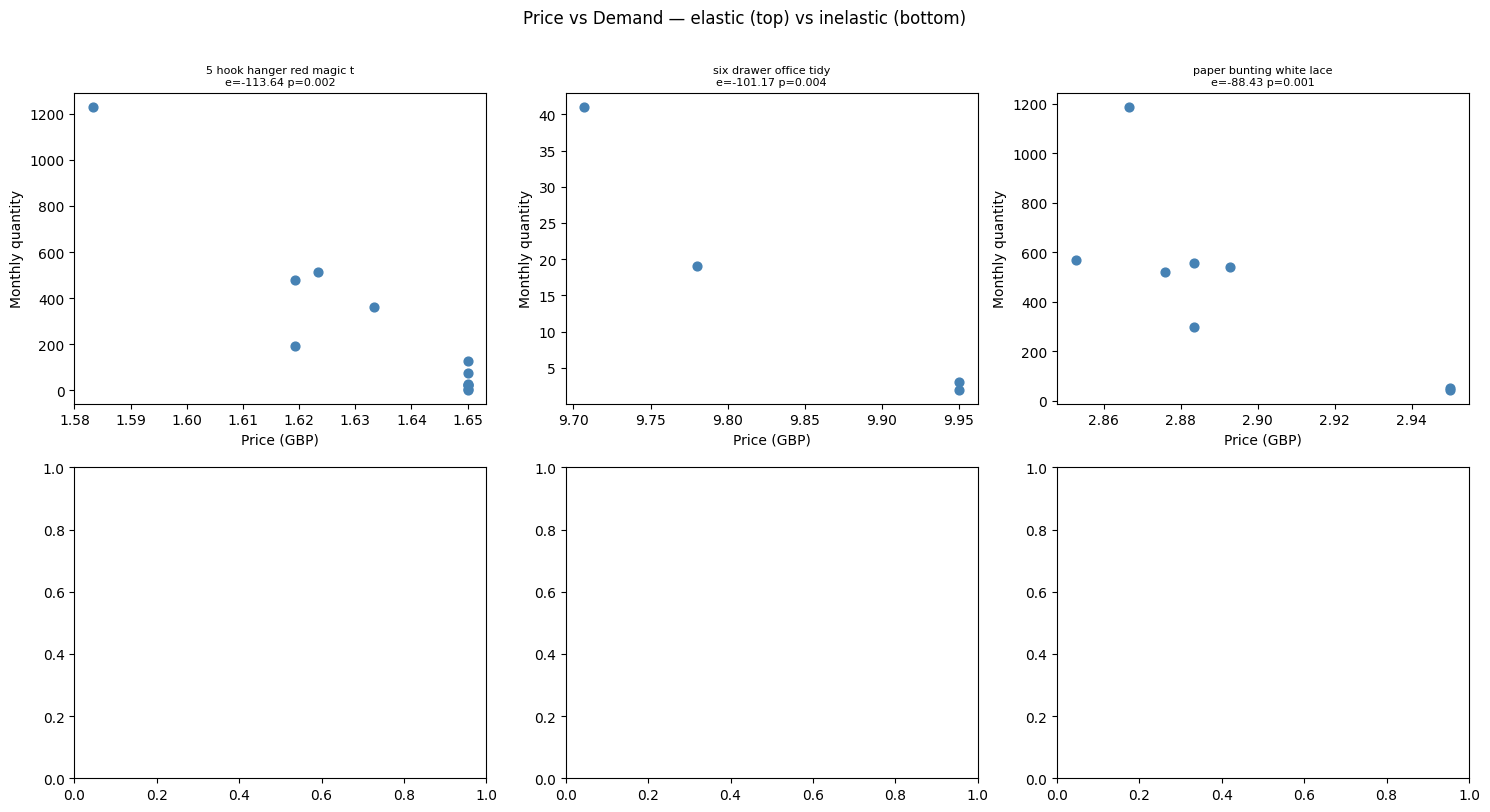

In [8]:
# Pick 6 interesting products — mix of elastic and inelastic
elastic_ex   = sig.nsmallest(3, 'elasticity')['StockCode'].tolist()
inelastic_ex = sig[(sig['elasticity'] > -0.5) & (sig['elasticity'] < 0)].nlargest(3, 'total_revenue')['StockCode'].tolist()
sample_skus  = elastic_ex + inelastic_ex

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sku in enumerate(sample_skus):
    sub  = monthly[monthly['StockCode'] == sku]
    info = elasticity_df[elasticity_df['StockCode'] == sku].iloc[0]
    axes[i].scatter(sub['avg_price'], sub['monthly_quantity'], color='steelblue', s=40)
    axes[i].set_xlabel('Price (GBP)')
    axes[i].set_ylabel('Monthly quantity')
    axes[i].set_title(f"{info['description'][:25]}\ne={info['elasticity']:.2f} p={info['p_value']:.3f}", fontsize=8)

plt.suptitle('Price vs Demand — elastic (top) vs inelastic (bottom)', y=1.01)
plt.tight_layout()
plt.show()

## 8. Save elasticity results

In [9]:
elasticity_df.to_parquet(PROCESSED / 'elasticity.parquet', index=False)
print(f'Saved elasticity.parquet — {len(elasticity_df):,} products')
print(f'\nFull summary:')
print(elasticity_df[['elasticity','r_squared','p_value','category']].describe().round(3))

Saved elasticity.parquet — 1,763 products

Full summary:
       elasticity  r_squared   p_value
count    1763.000   1763.000  1763.000
mean       -7.377      0.337     0.242
std        18.035      0.268     0.279
min      -149.068      0.000     0.000
25%        -8.743      0.092     0.020
50%        -1.992      0.300     0.114
75%        -0.692      0.530     0.394
max        61.968      1.000     0.998
